**Instalasi Library Tambahan**

In [68]:
!pip install folium

In [69]:
!pip install contextily

**Import Library Utama**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**Loading Dataset**

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
df = pd.read_csv("/content/drive/MyDrive/Hisyam Wildan Alfath/Semester 7/Machine Learning/Pertemuan 11/Praktikum dan Tugas Mandiri 11/data/data.csv")
df.head()

/tmp/ipython-input-766724693.py:1: DtypeWarning:

Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.



,province_id,province_name,city_id,city_name,district_id,district,npsn,school_name,stage,status,street_name,lat,long
0,250000,Papua,251800,Kab. Tolikara,251831,Kec. Gilungbandu,60303704,SMP SATAP KAGI,SMP,N,Gilubandu,-3.415995,138.339704
1,250000,Papua,251800,Kab. Tolikara,251822,Kec. Wunin,60302267,SD YPPGI WURINERI,SD,S,Wunin,-3.479000,138.680000
2,250000,Papua,251800,Kab. Tolikara,251803,Kec. Bokondini,60302279,SMAN BOKONDINI,SMA,N,MAIRINI,-3.531731,138.658234
3,250000,Papua,251800,Kab. Tolikara,251814,Kec. Kuari,60302215,SD INPRES KUARI,SD,N,Kuari,-3.518100,138.529500
4,250000,Papua,251800,Kab. Tolikara,251802,Kec. Karubaga,60302283,SMAS YPPGI KARUBAGA,SMA,S,AMPERA,-3.449100,138.598800


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215372 entries, 0 to 215371
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   province_id    215372 non-null  int64  
 1   province_name  215372 non-null  object 
 2   city_id        215372 non-null  int64  
 3   city_name      215372 non-null  object 
 4   district_id    215372 non-null  int64  
 5   district       215372 non-null  object 
 6   npsn           215372 non-null  object 
 7   school_name    215372 non-null  object 
 8   stage          215372 non-null  object 
 9   status         215372 non-null  object 
 10  street_name    215370 non-null  object 
 11  lat            214222 non-null  float64
 12  long           214222 non-null  float64
dtypes: float64(2), int64(3), object(8)
memory usage: 21.4+ MB


In [74]:
df.columns

Index(['province_id', 'province_name', 'city_id', 'city_name', 'district_id',
       'district', 'npsn', 'school_name', 'stage', 'status', 'street_name',
       'lat', 'long'],
      dtype='object')

**Data Cleaning (Pembersihan Data)**

In [75]:
df.isnull().sum()

,0
province_id,0
province_name,0
city_id,0
city_name,0
district_id,0
district,0
npsn,0
school_name,0
stage,0
status,0


In [76]:
df = df.dropna(subset=['street_name', 'lat', 'long']).copy()

In [77]:
df.isnull().sum()

,0
province_id,0
province_name,0
city_id,0
city_name,0
district_id,0
district,0
npsn,0
school_name,0
stage,0
status,0


In [78]:
df['stage'].unique()

array(['SMP', 'SD', 'SMA', 'SMK', 'SLB', 'SDLB', 'SMLB', 'SMPLB'],
      dtype=object)

In [79]:
mapping_stage = {
    'SD': 1,
    'SDLB': 1,
    'SMP': 2,
    'SMPLB': 2,
    'SMA': 3,
    'SMLB': 3,
    'SMK': 4,
    'SLB': 5
}

df['stage'] = df['stage'].replace(mapping_stage)

/tmp/ipython-input-3675227720.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [80]:
df['stage'].unique()

array([2, 1, 3, 4, 5])

In [81]:
df.head()

,province_id,province_name,city_id,city_name,district_id,district,npsn,school_name,stage,status,street_name,lat,long
0,250000,Papua,251800,Kab. Tolikara,251831,Kec. Gilungbandu,60303704,SMP SATAP KAGI,2,N,Gilubandu,-3.415995,138.339704
1,250000,Papua,251800,Kab. Tolikara,251822,Kec. Wunin,60302267,SD YPPGI WURINERI,1,S,Wunin,-3.479000,138.680000
2,250000,Papua,251800,Kab. Tolikara,251803,Kec. Bokondini,60302279,SMAN BOKONDINI,3,N,MAIRINI,-3.531731,138.658234
3,250000,Papua,251800,Kab. Tolikara,251814,Kec. Kuari,60302215,SD INPRES KUARI,1,N,Kuari,-3.518100,138.529500
4,250000,Papua,251800,Kab. Tolikara,251802,Kec. Karubaga,60302283,SMAS YPPGI KARUBAGA,3,S,AMPERA,-3.449100,138.598800


**Exploratory Data Analysis (EDA)**

In [82]:
import folium
from folium.plugins import HeatMap

# Buat peta dasar Indonesia
peta_indonesia = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Buat list data [lat, long, value] untuk heatmap
data_heatmap = df[['lat', 'long', 'stage']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta_indonesia)

# Tampilkan peta
peta_indonesia

Output hidden; open in https://colab.research.google.com to view.

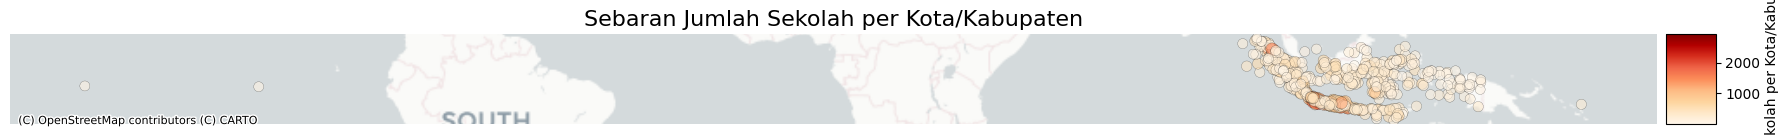

In [83]:
import geopandas as gpd
from shapely.geometry import Point
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import matplotlib.pyplot as plt

school_count_city = df.groupby('city_name').size().reset_index(name='school_count_city')

geometry = [Point(xy) for xy in zip(df['long'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

cities_gdf = df.groupby(['city_name', 'city_id']).agg(
    lat=('lat', 'mean'),
    long=('long', 'mean'),
    school_count_city=('school_name', 'count')
).reset_index()
cities_gdf['geometry'] = [Point(xy) for xy in zip(cities_gdf['long'], cities_gdf['lat'])]
cities_gdf = gpd.GeoDataFrame(cities_gdf, crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(18, 6))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cities_gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column="school_count_city",
    cmap="OrRd",
    legend=True,
    legend_kwds={"label": "Jumlah Sekolah per Kota/Kabupaten", "orientation": "vertical"},
    cax=cax,
    markersize=cities_gdf['school_count_city'].apply(lambda x: x / 50 + 50), # Scale markers by count
    edgecolor="black",
    linewidth=0.2,
    alpha=0.6
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Sebaran Jumlah Sekolah per Kota/Kabupaten", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

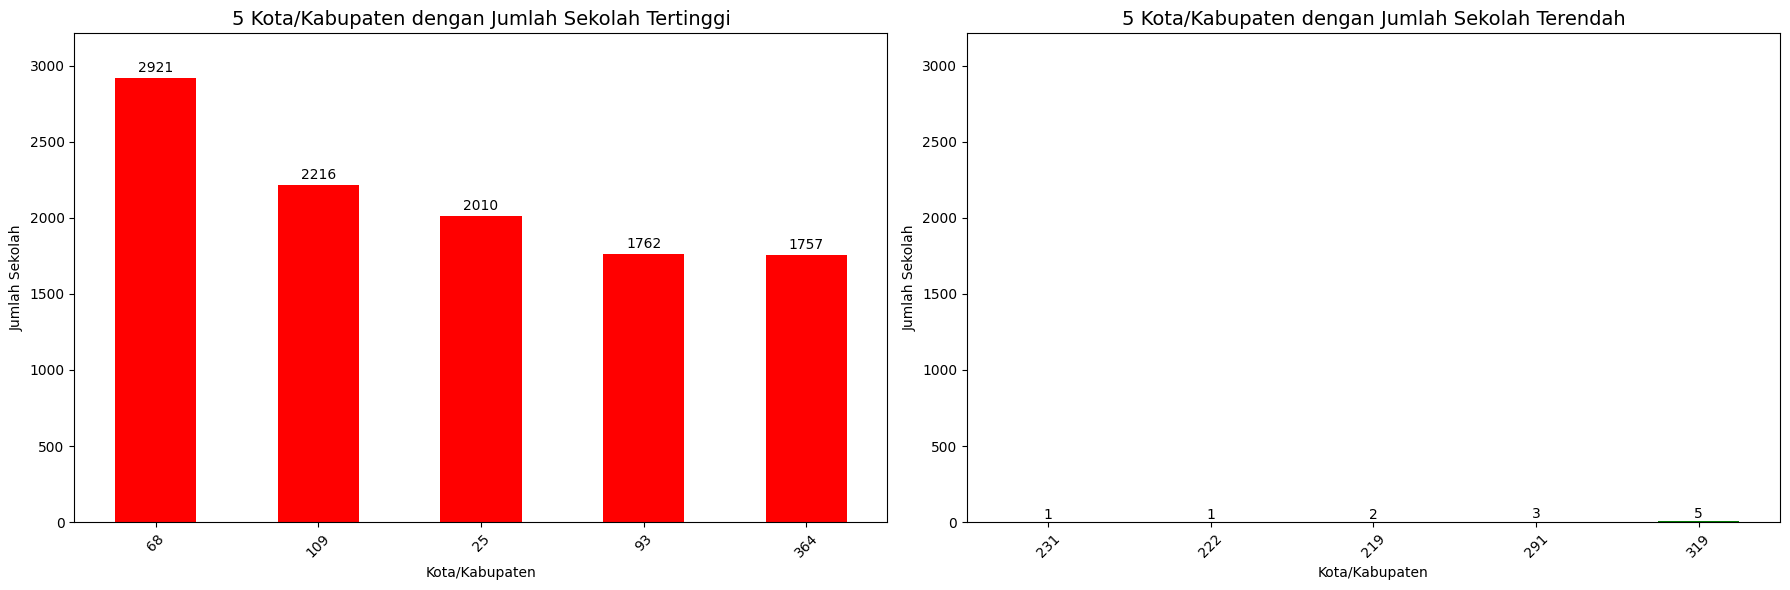

In [84]:
top_5 = school_count_city.sort_values(by='school_count_city', ascending=False).head(5)['school_count_city']
bottom_5 = school_count_city.sort_values(by='school_count_city', ascending=True).head(5)['school_count_city']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---------------- TOP 5 ----------------
ax_top = axes[0]
top_5.plot(kind="bar", ax=ax_top, color="red")
ax_top.set_title("5 Kota/Kabupaten dengan Jumlah Sekolah Tertinggi", fontsize=14)
ax_top.set_ylabel("Jumlah Sekolah")
ax_top.set_xlabel("Kota/Kabupaten")
ax_top.tick_params(axis="x", rotation=45)

for i, val in enumerate(top_5):
    ax_top.text(i, val + 20, f"{val:.0f}", ha="center", va="bottom", fontsize=10)

# ---------------- BOTTOM 5 ----------------
ax_bottom = axes[1]
bottom_5.plot(kind="bar", ax=ax_bottom, color="green")
ax_bottom.set_title("5 Kota/Kabupaten dengan Jumlah Sekolah Terendah", fontsize=14)
ax_bottom.set_ylabel("Jumlah Sekolah")
ax_bottom.set_xlabel("Kota/Kabupaten")
ax_bottom.tick_params(axis="x", rotation=45)

for i, val in enumerate(bottom_5):
    ax_bottom.text(i, val + 1, f"{val:.0f}", ha="center", va="bottom", fontsize=10)

max_val = max(top_5.max(), bottom_5.max())
ax_top.set_ylim(0, max_val * 1.1)
ax_bottom.set_ylim(0, max_val * 1.1)

plt.tight_layout()
plt.show()

**Uji Normalitas**

In [85]:
from scipy.stats import shapiro

normalityTest_df = df.drop(
    columns=[
        'province_name',
        'city_name',
        'district',
        'school_name',
        'stage',
        'status',
        'street_name',
        'lat',
        'long'
    ]
)


normalityTest_df = normalityTest_df.apply(pd.to_numeric, errors='coerce')

# Cek struktur DataFrame baru
normalityTest_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214220 entries, 0 to 215371
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   province_id  214220 non-null  int64  
 1   city_id      214220 non-null  int64  
 2   district_id  214220 non-null  int64  
 3   npsn         214189 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 8.2 MB


In [86]:
# Uji normalitas Shapiro–Wilk untuk seluruh kolom numerik
for col in normalityTest_df.columns:
    data = normalityTest_df[col].dropna()

    stat, p = shapiro(data)

    print(f"Kolom : {col}")
    print("  Statistik Shapiro-Wilk :", stat)
    print("  P-value                :", p)

    if p > 0.05:
        print("  Kesimpulan             : Data berdistribusi normal (tidak tolak H0)\n")
    else:
        print("  Kesimpulan             : Data TIDAK berdistribusi normal (tolak H0)\n")

Kolom : province_id
  Statistik Shapiro-Wilk : 0.877528298267372
  P-value                : 2.116652474056783e-134
  Kesimpulan             : Data TIDAK berdistribusi normal (tolak H0)

Kolom : city_id
  Statistik Shapiro-Wilk : 0.8765567922238213
  P-value                : 1.2196549467471533e-134
  Kesimpulan             : Data TIDAK berdistribusi normal (tolak H0)

Kolom : district_id
  Statistik Shapiro-Wilk : 0.8765508515547438
  P-value                : 1.2155648617859127e-134
  Kesimpulan             : Data TIDAK berdistribusi normal (tolak H0)

Kolom : npsn
  Statistik Shapiro-Wilk : 0.8126740065363767
  P-value                : 1.396828211608975e-147
  Kesimpulan             : Data TIDAK berdistribusi normal (tolak H0)



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 214220.

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 214189.



**Analisis Matriks Korelasi**

In [87]:
df['npsn'] = pd.to_numeric(df['npsn'], errors='coerce')

# Buat dataframe korelasi hanya berisi kolom numerik utama
correlation_df = df[['province_id', 'city_id', 'district_id', 'npsn']].copy()

correlation_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214220 entries, 0 to 215371
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   province_id  214220 non-null  int64  
 1   city_id      214220 non-null  int64  
 2   district_id  214220 non-null  int64  
 3   npsn         214189 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 8.2 MB


In [88]:
correlation_matrix = correlation_df.corr(method='spearman')
correlation_matrix

,province_id,city_id,district_id,npsn
province_id,1.000000,0.996536,0.996527,0.466783
city_id,0.996536,1.000000,0.999991,0.468969
district_id,0.996527,0.999991,1.000000,0.468988
npsn,0.466783,0.468969,0.468988,1.000000


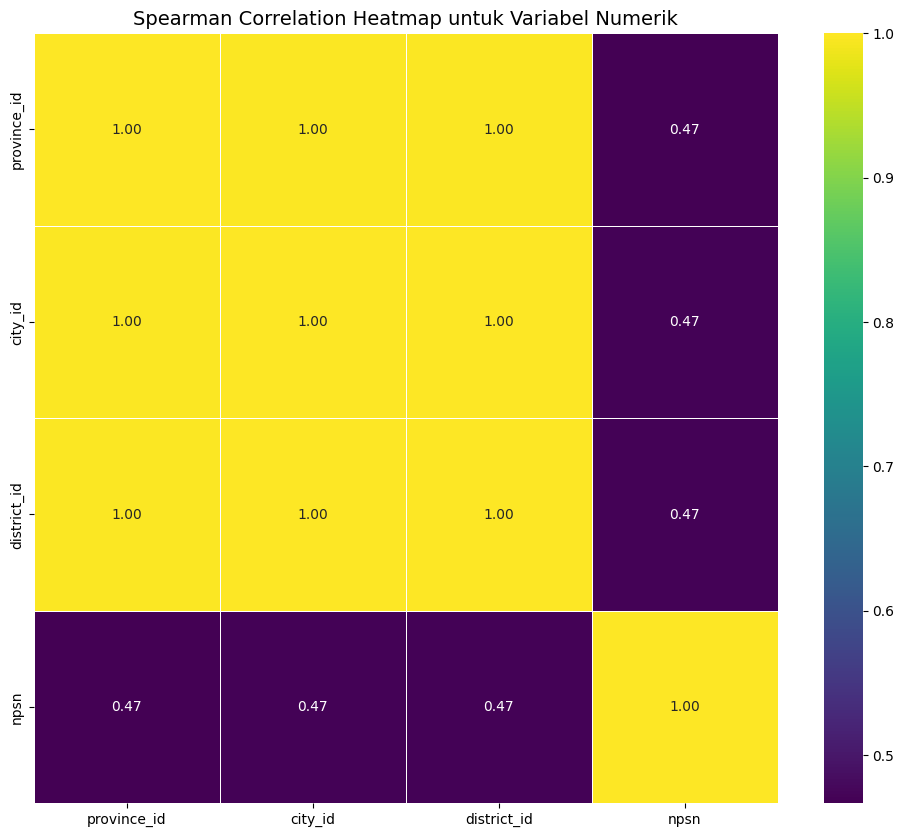

In [89]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap untuk Variabel Numerik", fontsize=14)
plt.show()

**Analisis Korelasi Spesifik**

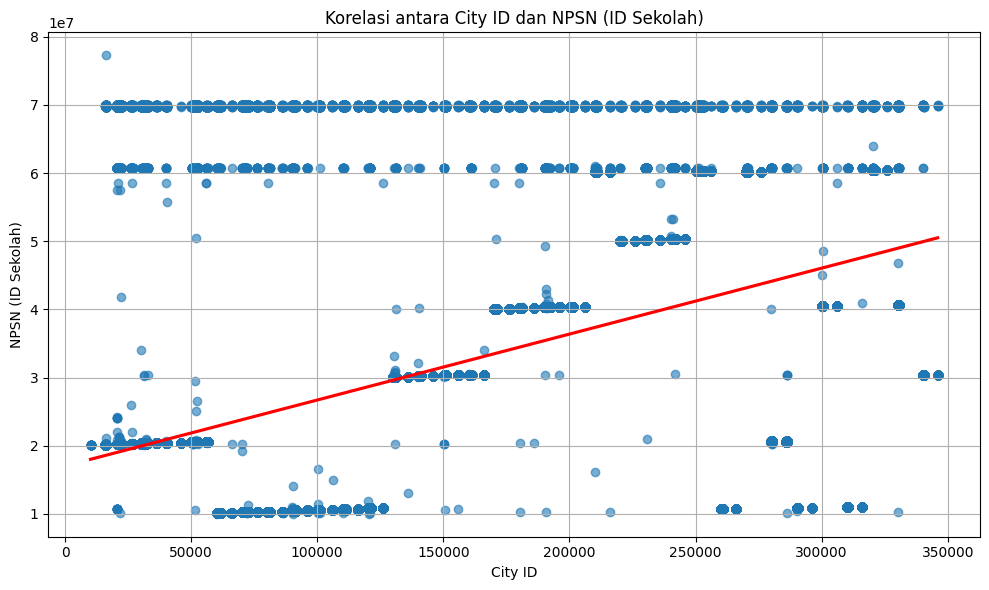

In [90]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='city_id',
    y='npsn',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title("Korelasi antara City ID dan NPSN (ID Sekolah)")
plt.xlabel("City ID")
plt.ylabel("NPSN (ID Sekolah)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Normalisasi Data**

In [91]:
df['npsn'] = pd.to_numeric(df['npsn'], errors='coerce')


normalisasi_df = df.drop(columns=[
    'province_name',
    'city_name',
    'district',
    'school_name',
    'stage',
    'status',
    'street_name',
    'lat',
    'long'
])

# Cek struktur dataframe setelah pembersihan
normalisasi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214220 entries, 0 to 215371
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   province_id  214220 non-null  int64  
 1   city_id      214220 non-null  int64  
 2   district_id  214220 non-null  int64  
 3   npsn         214189 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 8.2 MB


In [92]:
from sklearn.preprocessing import RobustScaler

column_names = normalisasi_df.columns
scaler = RobustScaler()
normalisasi_scaled = scaler.fit_transform(normalisasi_df)
normalisasi_df = pd.DataFrame(normalisasi_scaled, columns=column_names)
normalisasi_df.head()

,province_id,city_id,district_id,npsn
0,1.2,1.183042,1.183168,1.989908
1,1.2,1.183042,1.183107,1.989836
2,1.2,1.183042,1.182979,1.989837
3,1.2,1.183042,1.183053,1.989834
4,1.2,1.183042,1.182973,1.989837


**Menentukan Parameter ε (epsilon) menggunakan K-Distance Graph**

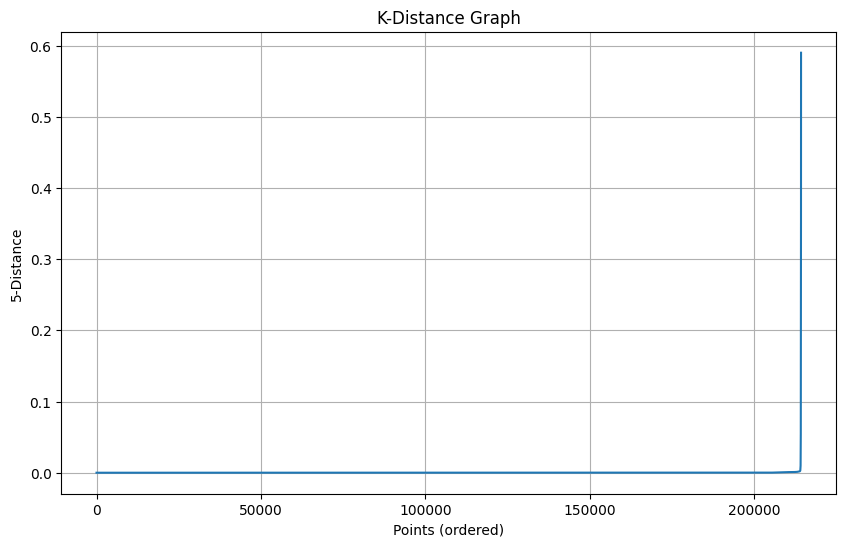

In [93]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X = normalisasi_df.dropna().values
k = 5

neighbors = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = neighbors.kneighbors(X)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

**Clustering dengan DBSCAN**

In [94]:
from sklearn.cluster import DBSCAN

normalisasi_clean = normalisasi_df.dropna()
sample_df = normalisasi_clean.sample(15000, random_state=42)

dbscan = DBSCAN(eps=0.55, min_samples=5)
labels = dbscan.fit_predict(sample_df.values)

sample_df["Cluster_DBSCAN"] = labels
print(sample_df["Cluster_DBSCAN"].value_counts())

Cluster_DBSCAN
0    14019
1      758
2      223
Name: count, dtype: int64


**Evaluasi Kualitas Clustering menggunakan Silhouette Score**

In [95]:
from sklearn.metrics import silhouette_score

labels = sample_df["Cluster_DBSCAN"].values
mask = labels != -1

X_sil = sample_df.drop(columns=["Cluster_DBSCAN"]).values

score = silhouette_score(X_sil[mask], labels[mask])
print("Silhouette Score:", score)

Silhouette Score: 0.36221394276649915


**Visualisasi Hasil Clustering dengan PCA (2D)**

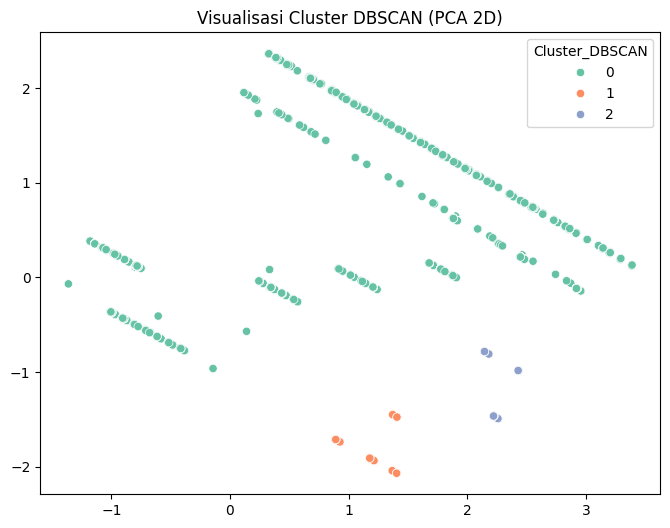

In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(sample_df.drop(columns=["Cluster_DBSCAN"]))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=sample_df["Cluster_DBSCAN"],
    palette="Set2"
)
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.show()

**Pengelompokan Kualitatif Cluster**

In [97]:
def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

sample_df["Klasifikasi_DBSCAN"] = sample_df["Cluster_DBSCAN"].apply(klasifikasi_db)

print(sample_df["Klasifikasi_DBSCAN"].value_counts())

Klasifikasi_DBSCAN
Baik      14019
Kurang      981
Name: count, dtype: int64


**Analisis Lanjutan per Cluster**

In [98]:
cluster_summary_db = (
    sample_df
    .groupby("Klasifikasi_DBSCAN")
    .mean(numeric_only=True)
)

cluster_summary_db

,province_id,city_id,district_id,npsn,Cluster_DBSCAN
Klasifikasi_DBSCAN,,,,,
Baik,0.184278,0.157648,0.157609,0.388045,0.000000
Kurang,1.469929,1.454770,1.454758,0.053293,1.227319


**Visualisasi Interaktif Persebaran Cluster**

In [99]:
import plotly.express as px
import pandas as pd

df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = sample_df["Klasifikasi_DBSCAN"].values
df_pca_db["ID"] = sample_df.index.astype(str)  # dipakai untuk hover

fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="ID",
    title="Persebaran Data Berdasarkan Klasifikasi DBSCAN",
    width=1000,
    height=700
)

fig.show()